# Experiment — Effect of scaling & standardization

**Category:** scaling

Do we need to scale features? It depends on the model. Distance/gradient-based models (linear, SVM, KNN, neural nets) are sensitive to feature magnitude; tree-based models (RandomForest, GradientBoosting) split on thresholds and are **scale-invariant**. We test 4 scalers × several models with 5-fold CV RMSE and visualise the result.

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid")

REPO = Path.cwd()
while not (REPO / "data").exists() and REPO != REPO.parent:
    REPO = REPO.parent
FIGS = REPO / "reports" / "figures"; FIGS.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(REPO / "data" / "processed" / "grid_load_clean.csv")
print("clean data:", df.shape)

clean data: (1489, 10)


In [2]:
# --- Feature engineering, written out inline ---
def make_features(frame):
    d = frame.copy()
    d["Hour_sin"] = np.sin(2*np.pi*d["Hour"]/24); d["Hour_cos"] = np.cos(2*np.pi*d["Hour"]/24)
    d["DoW_sin"]  = np.sin(2*np.pi*d["DayOfWeek"]/7); d["DoW_cos"] = np.cos(2*np.pi*d["DayOfWeek"]/7)
    d["is_weekend"]      = (d["DayOfWeek"] >= 5).astype(int)
    d["is_daytime"]      = d["Hour"].between(6, 18).astype(int)
    d["is_evening_peak"] = d["Hour"].between(18, 22).astype(int)
    d["Temp_x_Humidity"]  = d["Temperature_C"] * d["Humidity_pct"]
    d["Pop_x_Industrial"] = d["PopulationIndex"] * d["IndustrialIndex"]
    d = pd.concat([d.drop(columns=["Region"]),
                   pd.get_dummies(d["Region"], prefix="Region").astype(int)], axis=1)
    return d

feat = make_features(df)
y = feat["GridLoad_MW"]
X = feat.drop(columns=["GridLoad_MW"]).select_dtypes("number")
print("feature matrix:", X.shape)

feature matrix: (1489, 21)


## Why scaling could matter here
Our features live on wildly different scales — one-hot flags (0/1) next to `Pop_x_Industrial` (thousands). Look at the spread of column magnitudes:

In [3]:
X.describe().T[['min','max','mean','std']].round(2)

,min,max,mean,std
Hour,0.00,23.00,11.99,7.06
DayOfWeek,0.00,6.00,3.05,2.01
Temperature_C,18.00,35.00,26.52,4.97
Humidity_pct,35.00,95.00,64.11,17.54
Rainfall_mm,0.00,18.40,4.10,3.96
PopulationIndex,50.00,100.00,75.13,14.55
IndustrialIndex,20.00,95.00,57.87,21.75
SolarGenerationIndex,0.00,0.97,0.24,0.22
Hour_sin,-1.00,1.00,-0.04,0.70
Hour_cos,-1.00,1.00,0.03,0.71


## Compare scalers x models (5-fold CV RMSE)
Scalers: none, StandardScaler (z-score), MinMaxScaler (0–1), RobustScaler (median/IQR). Each is put in a Pipeline so scaling is fit on train folds only (no leakage).

In [4]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

scalers = {'none': None, 'Standard': StandardScaler(),
           'MinMax': MinMaxScaler(), 'Robust': RobustScaler()}
models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.1),
    'KNN': KNeighborsRegressor(n_neighbors=7),
    'SVR': SVR(C=10),
    'RandomForest': RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(random_state=42),
}
cv = KFold(n_splits=5, shuffle=True, random_state=42)

def cv_rmse(estimator):
    s = cross_val_score(estimator, X, y, cv=cv, scoring='neg_root_mean_squared_error', n_jobs=-1)
    return -s.mean()

table = {}
for mname, model in models.items():
    row = {}
    for sname, scaler in scalers.items():
        est = model if scaler is None else Pipeline([('scale', scaler), ('m', model)])
        row[sname] = cv_rmse(est)
    table[mname] = row
res = pd.DataFrame(table).T[['none','Standard','MinMax','Robust']].round(3)
res

/home/winzer/code/python/class/aion-gridload/.venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/winzer/code/python/class/aion-gridload/.venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/winzer/code/python/class/aion-gridload/.venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.


/home/winzer/code/python/class/aion-gridload/.venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/winzer/code/python/class/aion-gridload/.venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/winzer/code/python/class/aion-gridload/.venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.


/home/winzer/code/python/class/aion-gridload/.venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/winzer/code/python/class/aion-gridload/.venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/winzer/code/python/class/aion-gridload/.venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.


/home/winzer/code/python/class/aion-gridload/.venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/winzer/code/python/class/aion-gridload/.venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/winzer/code/python/class/aion-gridload/.venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.


/home/winzer/code/python/class/aion-gridload/.venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/winzer/code/python/class/aion-gridload/.venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(


...

/home/winzer/code/python/class/aion-gridload/.venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/winzer/code/python/class/aion-gridload/.venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/winzer/code/python/class/aion-gridload/.venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.


/home/winzer/code/python/class/aion-gridload/.venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/winzer/code/python/class/aion-gridload/.venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/winzer/code/python/class/aion-gridload/.venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.


/home/winzer/code/python/class/aion-gridload/.venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/winzer/code/python/class/aion-gridload/.venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/winzer/code/python/class/aion-gridload/.venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.


/home/winzer/code/python/class/aion-gridload/.venv/lib64/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(


,none,Standard,MinMax,Robust
LinearRegression,12.752,12.752,12.752,12.752
Ridge,12.754,12.758,13.094,12.806
Lasso,12.796,12.745,12.832,12.779
KNN,33.426,47.188,56.825,38.715
SVR,32.468,21.727,20.221,21.923
RandomForest,18.691,18.672,18.693,18.690
GradientBoosting,12.729,12.719,12.709,12.729


## Visualise: scaling sensitivity heatmap
Rows that change across columns are scale-sensitive; flat rows are scale-invariant.

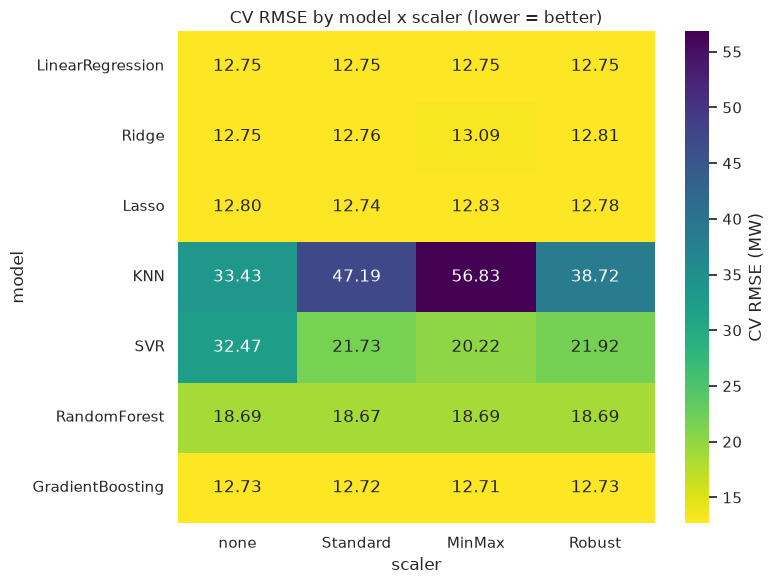

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(res, annot=True, fmt='.2f', cmap='viridis_r', ax=ax, cbar_kws={'label':'CV RMSE (MW)'})
ax.set_title('CV RMSE by model x scaler (lower = better)')
ax.set_xlabel('scaler'); ax.set_ylabel('model')
fig.tight_layout(); fig.savefig(FIGS/'scaling_heatmap.png', dpi=120); plt.show()

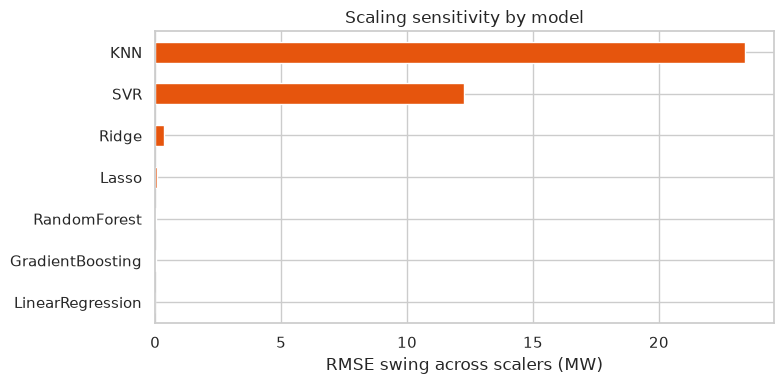

KNN                 23.399
SVR                 12.247
Ridge                0.340
Lasso                0.087
RandomForest         0.021
GradientBoosting     0.020
LinearRegression     0.000
dtype: float64

In [6]:
# how much does scaling move each model? (max - min across scalers)
sensitivity = (res.max(axis=1) - res.min(axis=1)).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8,4))
sensitivity.plot.barh(ax=ax, color='#e6550d'); ax.invert_yaxis()
ax.set_xlabel('RMSE swing across scalers (MW)')
ax.set_title('Scaling sensitivity by model')
fig.tight_layout(); fig.savefig(FIGS/'scaling_sensitivity.png', dpi=120); plt.show()
sensitivity.round(3)

## Findings

- **SVR is hugely scale-sensitive** — RMSE ~32 (no scaling) → ~20 with MinMax/Standard. Margin/distance models must be scaled.
- **KNN is scale-sensitive too**, but every variant (~33–57) is far worse than the tree/linear models here — the many 0/1 one-hot & flag columns make plain Euclidean distance a poor fit regardless of scaler.
- **Linear models** (Linear/Ridge/Lasso) barely move (~12.75); already well-conditioned. Scaling matters mainly for fair Lasso regularisation.
- **Tree ensembles (RandomForest, GradientBoosting)** are essentially flat across all scalers (GBM ~12.71–12.73) — **scaling is unnecessary** for them.
- **Decision for the final model:** the chosen model is GradientBoosting → **no scaling applied**. If an SVR/KNN/linear model were selected, a `StandardScaler` (or `RobustScaler`, given the outliers cleaned in Tasks 1–3) would go inside the pipeline to prevent leakage.
